# Discord moderation triage

**Recipe 16** · Level 2 (Easy) · Decision type: `Choice`

Classify sample Discord messages as allowed, review-needed, or potentially violating a supplied community rule to populate a simulated moderator queue.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A small moderation triage tool for a fabricated Discord server. Jev reads one message, together with the server's own community rule, and picks exactly one of three fixed categories: `review_needed` (the explicit uncertain outcome, for a message whose tone or context a reader cannot be sure of), `potentially_violating`, or `allowed`. Python owns everything else: the state Jev sees, the identifiers that never reach the model, and a rule that turns the category and its confidence into one of four simulated moderation actions -- `ignore`, `warn`, `hide`, or `escalate` to a person -- through `jev_cookbook.simulation`'s `ActionLog` and `ReviewQueue`. Every category, `allowed` included, passes through the same confidence gate before anything happens: the standard three-path pattern, applied alike rather than carving out an exemption. Nothing here posts, deletes, or sends anything to a real server. By the end you will have looked at individual typed answers across the hard cases this use case names -- sarcasm, a message that only quotes or reports someone else's abusive words, borderline banter, and a benign message that merely contains a word the rule's examples mention -- seen the rule that turns them into simulated actions, and run an evaluation over 41 synthetic messages (19 `validation`, 20 `test`, 2 `demo`) that reports a confusion matrix, the separate cost of a false allow against a false flag, and the coverage, accuracy and risk the gate produces.


## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 41 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which [run mode](../../docs/glossary.md#run-mode) ran, and every number below carries that mode with it.


In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()  # {id: gold label}, one per validation/test example
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 41 examples in fixtures/ needs at most one request. This cache makes sure a
# message that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 41 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "triage"
        ]
    return answered[example.id]


run_header(
    16,
    "Discord moderation triage",
    backend=backend,
    n_examples=len(scored),
)

Recipe 16: Discord moderation triage
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 39 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The [state](../../docs/glossary.md#state) is everything Jev sees, and Python builds it. Every message in this recipe is checked against the same community rule, `helpers.RULE_TEXT`, so `build_state` attaches it to every request alongside the message text. Each example in `fixtures/inputs.jsonl` also carries a `message_id` and an `author`; Python keeps both to itself and attaches them to the outcome at the end, so an identifier never passes through the model and every result still traces back to its message.


In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-trigger-word"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "message_id": "MSG-7001",
  "author": "nova_badger",
  "message": "I'm going to kill this raid boss tonight if it's the last thing I do, let's go"
}
Jev sees:
{
  "rule": "Lumen Games Community conduct rule: be respectful. Do not harass, threaten, demean, or target a member for who they are. No hate speech, no threats of violence or self-harm, and no sharing someone else's private information. Friendly joking between members who both enjoy it is fine; it stops being fine the moment it singles someone out or makes them a target.",
  "message": "I'm going to kill this raid boss tonight if it's the last thing I do, let's go"
}


## The questions

There is one question, and it asks one thing: given the rule above, which of three categories does the message belong to? A [`Choice`](../../docs/glossary.md#choice) fits because the categories are exclusive and Jev should commit to one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no order between them; the option set here is built by Python, not invented by the model). `allowed` and `potentially_violating` are the two outcomes the use case names directly; `review_needed` is the explicit uncertain outcome Level 2 scope asks for, for a message whose tone or context a reader cannot be sure of -- not a confidence artifact Python adds on top, but a category the question itself offers on equal footing with the other two. The two flagged categories' descriptions say what belongs to the other instead, for the pair that is easiest to confuse: a message that quotes or reports someone else's abusive words belongs to `review_needed`, not `potentially_violating`, even when the quoted words are harsh ([S07](https://docs.typesafe.ai/model-jaggedness/jev-1.13) item 6, "adversarial content": the documentation says Jev does not treat the state as hostile by default, so a message that only *carries* hostile words can read as hostile itself unless told otherwise). Each description is prose with the "what belongs to the other option instead" clause folded in, rather than TypeSafe's structured `what`/`not_for`/`examples` object shape (`jev_cookbook.Choice` accepts either, a plain string or a JSON object, per option); prose reads naturally here because the clause is one sentence, not a list.

The instructions ask about the rule directly rather than leaving it implicit, because [S07](https://docs.typesafe.ai/model-jaggedness/jev-1.13) item 8 notes a lean toward whichever option comes first in a close call. That lean, if present, points in one direction: toward whichever category is listed first, every time. The options below are listed `review_needed`, `potentially_violating`, `allowed` -- `allowed` last, not first -- so that a tie-breaking lean favours a message being flagged rather than let through, instead of favouring the one category this recipe's rule can act on with no side effect.

A `Choice` answer's [`confidence`](../../docs/glossary.md#confidence) is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): with three options, 0 when the top option holds no more than a third of the probability, 1 when one option holds all of it. A low confidence does not mean a message is unreadable; it means the top category did not pull far ahead of an even third, which is often the honest shape for a genuinely ambiguous message's probabilities to take.


In [3]:
triage = questions["triage"]
print(triage.instructions)
print()
for name, description in triage.criteria.items():
    print(f"{name}:")
    print(f"  {description}")
    print()

Given the community rule above, which of these three categories does the message belong to?

review_needed:
  The message does not clearly fit allowed or potentially_violating: its tone depends on context a reader cannot be sure of (sarcasm that could be read either way, banter that might or might not be welcome to the person on the other end, a vague message that could be about someone specific), or it quotes or describes someone else's abusive words -- for example reporting what another member said -- rather than being abusive in its own words. A person should look at it.

potentially_violating:
  The message's own words harass, threaten, demean, or target a member for who they are, share someone's private information, or otherwise cross the rule above. This is about what the message itself says, not about a word it merely contains or a quotation it carries: a message that reports or quotes someone else's abusive words belongs to review_needed instead, even when those quoted words ar

## One answer up close

Before any aggregate number, look at three typed answers that cover this recipe's hard cases: a benign message that merely contains a word the rule's examples mention, a message that reports someone else's abusive words rather than being abusive itself, and one this recipe's stored answer gets wrong. Each answer holds the chosen category, a probability for every category, the `confidence` explained above, and a [`provenance`](../../docs/glossary.md#provenance) line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.


I'm going to kill this raid boss tonight if it's the last thing I do, let's go
Choice: allowed (confidence 0.77)
  allowed                0.85  #################
  review_needed          0.10  ##
  potentially_violating  0.05  #
Provenance: synthetic


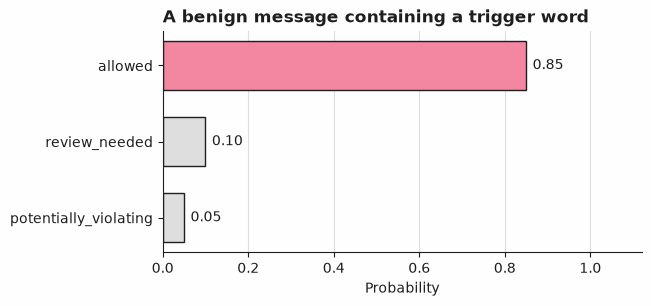

In [4]:
trigger_example = demo["d01-trigger-word"]
trigger_answer = decide(trigger_example)
print(trigger_example.fields["message"])
show_answer(trigger_answer)
plot_answer_probabilities(trigger_answer, title="A benign message containing a trigger word")

"I'm going to kill this raid boss tonight" uses a word the rule's examples mention ("threats of violence"), but the target is a video game boss, not a person: the message is harmless, and this fixture's stored answer puts `allowed` clearly ahead at 0.85 (`confidence` 0.775, `(0.85 - 1/3) / (1 - 1/3)`). This is the context-sensitive matching Level 2 scope asks for: a rule that only checked for the word "kill" would flag this message for nothing.


In [5]:
quoted_example = demo["d02-quoted-report"]
quoted_answer = decide(quoted_example)
print(quoted_example.fields["message"])
show_answer(quoted_answer)

can someone check this? misty_falcon told me 'you're an idiot and should just leave' in dms
Choice: review_needed (confidence 0.62)
  review_needed          0.75  ###############
  potentially_violating  0.15  ###
  allowed                0.10  ##
Provenance: synthetic


This message reports what someone else said; its own words ask a moderator to look at that, and do not themselves harass anyone. This fixture's stored answer correctly leans toward `review_needed` at 0.75 (`confidence` 0.6250), not `potentially_violating`: a person should still look at it, because the words it quotes are harsh and Python cannot verify from the message alone that the quote is accurate or complete, but the message itself is not the violation.


In [6]:
wrong_example = next(e for e in examples if e.id == "v07-quoted-abuse")
wrong_answer = decide(wrong_example)
print(wrong_example.fields["message"])
show_answer(wrong_answer)

can a mod look at this? dax told me 'nobody wants you here, just quit already' in general chat yesterday
Choice: potentially_violating (confidence 0.67)
  potentially_violating  0.78  ################
  review_needed          0.17  ###
  allowed                0.05  #
Provenance: synthetic


This message is the same shape as the one above -- reporting someone else's abusive words -- and its [gold label](../../docs/glossary.md#gold-label) (the correct category this recipe's fixtures record for evaluation, decided in advance by the rule each option's description states, never by Jev) is also `review_needed`. This fixture's stored answer gets it wrong, confidently: `potentially_violating` at 0.78 (`confidence` 0.6700). This is the adversarial-content risk named above: the quoted words ("nobody wants you here, just quit already") are themselves hostile, and a literal reading of the message's content, without weighing that those words are attributed to someone else, mistakes the report for the violation in this stored answer. `test` carries the same shape of mistake once more (`t07-quoted-abuse`, below); both scored examples of this hard case land on the wrong side, so no scored example in this recipe shows the "quote or report belongs to review_needed" steering actually winning -- a jaggedness lesson about this pair of options, not a fixture bug. The evaluation below shows what Python's rule does about this exact kind of mistake, and what it does not catch.


## Python's part

Jev supplies the category; what happens next is code. `helpers.moderate` applies the standard three-path pattern to every category alike: a defensive membership check runs first (the backend already rejects an option outside the fixed set, but the rule does not trust that alone), and after that **every** category -- `allowed` included -- goes through the same confidence gate before anything else is decided. Below the gate, whatever category Jev named, the message is escalated to a simulated human moderator. Above it, the category decides the action: `allowed` resolves to `ignore` (no side effect, so there is nothing left for a later step to protect), a confident `review_needed` is warned rather than hidden -- the category itself already says the message's violation is not clear-cut -- and a confident `potentially_violating` is hidden. `warn` and `hide` share one gate rather than two separate ones, because both already name a definite category (not a probability a second cut-off would further resolve); a recipe that wanted to treat a hidden message as costlier to get wrong than a warned one would need a second, stricter gate for `hide` alone. `allowed` gets no exemption: a confidently wrong `allowed` answer leaves a message standing that a person never sees, which is exactly the consequence CONTRIBUTING.md section 4 asks an explicit review outcome to catch, not a side-effect-free result it is safe to skip past. `review_needed` is the option this use case actually names as fallback-shaped, and it is gated like everything else too. `tests/test_helpers.py` checks every branch of this rule for every category, so the claim "it holds whatever the model answers" is checked, not asserted.

The gate itself is chosen here, on `validation`, over every category at once -- not a subset of them -- and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest confidence whose answered subset is all correct, which is as much automatic coverage as this fixture set allows without accepting a wrong answer *on validation*. The gate is not pinned down to one exact value: the next lower confidence among validation's correct answers is 0.6700 (`v07-quoted-abuse`'s own, the one validation mistake), so any cut-off in the open interval `(0.6700, 0.7600]` would select the same accepted set here. Applying the frozen gate to the three answers shown above, plus a confidently `potentially_violating` message, a confidently `review_needed` one, and a correct but hesitant `allowed` one, demonstrates every action the rule can produce -- including the coverage this gate costs on a category that used to be exempt.


In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Every category is gated the same way now, so the gate is chosen from every validation answer,
# not a subset of them.
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen confidence gate, frozen from here on: {threshold:.4f}{selection}{check}")

violating_example = next(e for e in val_examples if e.id == "v04-violating-insult")
violating_answer = decide(violating_example)
sarcasm_example = next(e for e in val_examples if e.id == "v06-sarcasm")
sarcasm_answer = decide(sarcasm_example)
hesitant_example = next(e for e in val_examples if e.id == "v09-allowed-hesitant")
hesitant_answer = decide(hesitant_example)
for shown_example, shown_answer in (
    (trigger_example, trigger_answer),
    (quoted_example, quoted_answer),
    (wrong_example, wrong_answer),
    (violating_example, violating_answer),
    (sarcasm_example, sarcasm_answer),
    (hesitant_example, hesitant_answer),
):
    result = helpers.moderate(shown_example.fields["message_id"], shown_answer, threshold)
    print(
        f"{result.message_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.4f} "
        f"-> {result.action} ({result.reason})"
    )

chosen confidence gate, frozen from here on: 0.7600 (a selection step, not a reported result) (a pipeline check, not a Jev result)
MSG-7001: allowed at confidence 0.7750 -> ignore (confident allowed: no action)
MSG-7002: review_needed at confidence 0.6250 -> escalate (confidence below the threshold)
MSG-5007: potentially_violating at confidence 0.6700 -> escalate (confidence below the threshold)
MSG-5004: potentially_violating at confidence 0.8500 -> hide (confident potentially_violating: hide)
MSG-5006: review_needed at confidence 0.8050 -> warn (confident review_needed: warn, do not hide)
MSG-5009: allowed at confidence 0.4000 -> escalate (confidence below the threshold)


## Simulating the moderator queue

A message that does not clear the confidence gate is supposed to land in a simulated moderator queue, whatever category Jev named for it. `jev_cookbook.simulation.ActionLog` and `ReviewQueue` are the shared primitives for exactly this: `ActionLog.record` keeps a note that an action was *decided*, never executed, and `ReviewQueue.submit` keeps an escalated item, the reason it was sent, and the typed answer behind that reason, so a later cell can show why. The two `demo` messages shown above are illustrations, not scored traffic, so they never reach either one; this cell seeds both with every `validation` message instead (the 2 demo examples are the only ones left out). The "Evaluation" section below adds `test`'s messages to the same log and queue, so the queue grows exactly the way one would over two batches of real traffic.


In [8]:
action_log = ActionLog()
review_queue = ReviewQueue()


def act(example, answer, threshold):
    result = helpers.moderate(example.fields["message_id"], answer, threshold)
    item = {
        "message_id": result.message_id,
        "author": example.fields["author"],
        "category": result.label,
    }
    if result.action == helpers.ESCALATE:
        review_queue.submit(item, result.reason, answer=answer)
    else:
        action_log.record(result.action, item, answer=answer, rule="helpers.moderate")
    return result


val_results = [act(e, a, threshold) for e, a in zip(val_examples, val_answers, strict=True)]
print(f"action log after validation: {len(action_log)} entries{selection}{check}")
print(f"review queue after validation: {len(review_queue)} items{selection}{check}")
for item in review_queue.to_dicts():
    confidence = item["answer"]["confidence"]
    print(
        f"  {item['item']['message_id']}: {item['item']['category']} at confidence "
        f"{confidence:.4f} -- {item['reason']}"
    )

action log after validation: 12 entries (a selection step, not a reported result) (a pipeline check, not a Jev result)
review queue after validation: 7 items (a selection step, not a reported result) (a pipeline check, not a Jev result)
  MSG-5007: potentially_violating at confidence 0.6700 -- confidence below the threshold
  MSG-5008: review_needed at confidence 0.4750 -- confidence below the threshold
  MSG-5009: allowed at confidence 0.4000 -- confidence below the threshold
  MSG-5012: review_needed at confidence 0.4000 -- confidence below the threshold
  MSG-5015: review_needed at confidence 0.5200 -- confidence below the threshold
  MSG-5018: review_needed at confidence 0.4450 -- confidence below the threshold
  MSG-5019: review_needed at confidence 0.3250 -- confidence below the threshold


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.moderate` is applied to every example in `validation` and in `test` (via the same `act` function the queue above uses, never a separate reimplementation), and every number below comes from what it actually returned. Alongside that, `jev_cookbook.evaluation` reports a confusion matrix of the raw category against the gold label, and the cost of a false allow -- a message that should have been flagged but was called `allowed` -- discussed separately from a false flag -- an allowed message that was wrongly flagged. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries both labels.


test, 20 examples, confidence gate 0.7600 frozen (a pipeline check, not a Jev result)
accuracy of the raw category: 0.8000 (a pipeline check, not a Jev result)
confusion matrix, rows gold, columns predicted, in the order ['review_needed', 'potentially_violating', 'allowed'] (a pipeline check, not a Jev result)
  review_needed          [4, 1, 1] (a pipeline check, not a Jev result)
  potentially_violating  [0, 5, 1] (a pipeline check, not a Jev result)
  allowed                [0, 1, 7] (a pipeline check, not a Jev result)


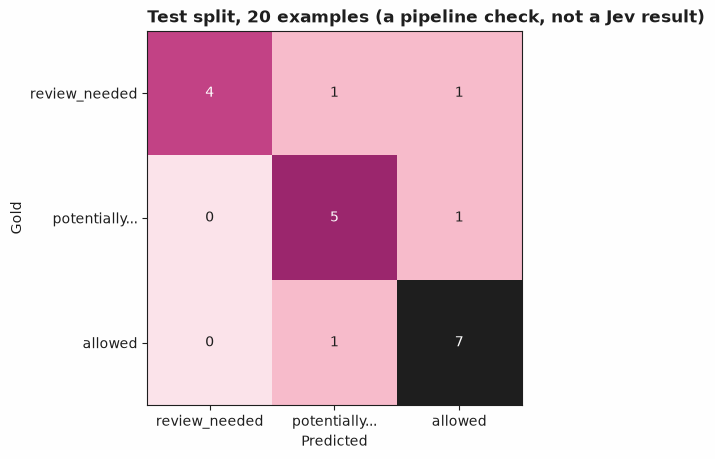

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

raw_accuracy = sum(a.choice == g for a, g in zip(test_answers, test_gold, strict=True)) / len(
    test_examples
)
print(f"test, {len(test_examples)} examples, confidence gate {threshold:.4f} frozen{check}")
print(f"accuracy of the raw category: {raw_accuracy:.4f}{check}")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
print(f"confusion matrix, rows gold, columns predicted, in the order {matrix.labels}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix, strict=True):
    print(f"  {gold_label:22s} {[int(x) for x in row]}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Two terms the next cell prints, defined before they are needed: **f1** is the harmonic mean of a category's precision and recall, a single number that is low whenever either one is; **support** is how many `test` examples actually carry that category as their gold label, so a recall figure next to a small support is less to hang a conclusion on than the same figure next to a large one.

A **false allow** is a message that should have been flagged (`review_needed` or `potentially_violating`) but was called `allowed`. A **false flag** is the opposite: an actually `allowed` message wrongly called `review_needed` or `potentially_violating`. Gating `allowed` like every other category does not make false allows impossible -- it makes them the same kind of mistake as a false flag: a message whose confident, wrong answer happened to clear the gate. `precision` below is the fraction of the rule's `allowed` calls that were actually right, and `recall` is the fraction of the truly-`allowed` messages the rule actually caught; a false allow costs `allowed`'s precision, and a false flag costs its recall.


In [10]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:22s} precision {counts.precision:.4f}  recall {counts.recall:.4f}  "
        f"f1 {counts.f1:.4f}  support {counts.support}{check}"
    )

false_allow = [
    e.id
    for e, a, g in zip(test_examples, test_answers, test_gold, strict=True)
    if a.choice == helpers.ALLOWED and g != helpers.ALLOWED
]
false_flag = [
    e.id
    for e, a, g in zip(test_examples, test_answers, test_gold, strict=True)
    if a.choice != helpers.ALLOWED and g == helpers.ALLOWED
]
print(f"false allow (flagged message called allowed): {false_allow}{check}")
print(f"false flag (allowed message called flagged): {false_flag}{check}")

review_needed          precision 1.0000  recall 0.6667  f1 0.8000  support 6 (a pipeline check, not a Jev result)
potentially_violating  precision 0.7143  recall 0.8333  f1 0.7692  support 6 (a pipeline check, not a Jev result)
allowed                precision 0.7778  recall 0.8750  f1 0.8235  support 8 (a pipeline check, not a Jev result)
false allow (flagged message called allowed): ['t15-false-allow', 't20-missed-violation'] (a pipeline check, not a Jev result)
false flag (allowed message called flagged): ['t17-false-flag'] (a pipeline check, not a Jev result)


`review_needed`'s own row above is this recipe's explicit uncertain outcome reported on its own, as the issue asks: its `recall`, 0.6667, means two of its six `test` messages were missed by the raw category entirely (one of them, `t15-false-allow` below, is a false allow this split's own gate does catch, once `allowed` is gated too).

`helpers.moderate`'s only *live* branch left, once every category is gated the same way, is the confidence gate itself -- the membership check never fires on any real fixture here. `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` reports coverage, accuracy and risk from the rule's own `ignore`/`warn`/`hide`/`escalate` outcomes, with `accepted` read from what `moderate` actually returned; `evaluate_selective(correct, confidence, threshold)` reports the same three numbers by reapplying `confidence >= threshold` directly, with no call into the rule at all. Printed side by side below, the two agree on every field but `threshold` (which `evaluate_outcomes` cannot report, since it never saw one) -- confirming, on this data, that the rule's only operative branch is the gate, so `evaluate_selective` is the helper that actually applies here, and `evaluate_outcomes` is shown only to demonstrate that it says the same thing. **coverage** is the fraction of messages answered automatically; **accuracy**, among those, is the fraction whose *category* matched the gold label (the action -- `ignore`/`warn`/`hide` -- is a function of the category once accepted, not a separate thing to compare against a gold label); **risk** is its complement, `1 - accuracy`.


In [11]:
val_accepted = [r.action != helpers.ESCALATE for r in val_results]
val_correct = [r.label == g for r, g in zip(val_results, val_gold, strict=True)]
val_outcomes = evaluate_outcomes(val_accepted, val_correct)
val_selective = evaluate_selective(val_correct, val_confidence, threshold)
assert (val_outcomes.coverage, val_outcomes.accuracy, val_outcomes.risk) == (
    val_selective.coverage,
    val_selective.accuracy,
    val_selective.risk,
)
print(
    f"validation: answered {val_outcomes.n_answered} of {val_outcomes.n_total} "
    f"(coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")
print(f"(evaluate_outcomes and evaluate_selective agree on all three){selection}{check}")

validation: answered 12 of 19 (coverage 0.6316) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
(evaluate_outcomes and evaluate_selective agree on all three) (a selection step, not a reported result) (a pipeline check, not a Jev result)


In [12]:
test_results = [act(e, a, threshold) for e, a in zip(test_examples, test_answers, strict=True)]
test_accepted = [r.action != helpers.ESCALATE for r in test_results]
test_correct = [r.label == g for r, g in zip(test_results, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
test_correct_raw = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_outcomes = evaluate_outcomes(test_accepted, test_correct)
test_selective = evaluate_selective(test_correct_raw, test_confidence, threshold)
assert (test_outcomes.coverage, test_outcomes.accuracy, test_outcomes.risk) == (
    test_selective.coverage,
    test_selective.accuracy,
    test_selective.risk,
)
print(
    f"test: answered {test_outcomes.n_answered} of {test_outcomes.n_total} "
    f"(coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")
print(f"(evaluate_outcomes and evaluate_selective agree on all three){check}")

test: answered 13 of 20 (coverage 0.6500) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8462 (a pipeline check, not a Jev result)
risk among those answered: 0.1538 (a pipeline check, not a Jev result)
(evaluate_outcomes and evaluate_selective agree on all three) (a pipeline check, not a Jev result)


`validation`'s risk is 0.0000: the gate was chosen so that no answer it accepts there is wrong. Its coverage, 0.6316, is lower than the 13 of 19 a reader might expect from the twelve previously-gated categories alone, because `v09-allowed-hesitant` -- correct, but only 0.4000 confident -- is escalated too now; that one example is the coverage this recipe's gate spends to also catch a wrong `allowed` answer, which `v07-quoted-abuse` (the one actual validation mistake, 0.6700 confident) shows it still does.

`test`'s risk is not zero, at 0.1538: two of its thirteen automatically-acted-on messages are wrong, and they are the two different costs named above, both confident enough to clear the gate. `t17-false-flag` is called `potentially_violating` at confidence 0.7750 when its gold label is `allowed`: ordinary competitive trash talk ("I'm going to destroy you in the next match") read as a threat in this fixture's stored answer -- hidden, a benign message wrongly removed. `t20-missed-violation` is called `allowed` at confidence 0.7750 when its gold label is `potentially_violating`: a passive-aggressive exclusionary remark ("no one would even notice if you just stopped showing up here") read as nothing, so it is ignored -- the cost the issue names, a message that actually violates the rule left standing, and confident enough that gating `allowed` does not catch it either. Gating `allowed` is not a guarantee against a false allow; it is the same single defence every other category gets, and it catches exactly the mistakes a gate can catch: `t15-false-allow`, at 0.7000, falls *below* the gate and is escalated instead of accepted, which is why it costs `test` nothing here, while `t17` and `t20`, both at 0.7750, clear it. A gate chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any message this recipe has not seen.


`test_results` above was already computed with the same `act` function the queue cells use, so every `test` message has already been logged or queued exactly once, alongside `validation`'s. This cell reads the totals and shows the queue in full. Neither `jev_cookbook.simulation.ActionLog` nor `ReviewQueue` executes anything: an `ActionLog` entry carries its own `executed` field, always `False` by construction, and a `ReviewQueue` item carries a `status` field (`"pending"` until a person resolves it, which nothing here does) -- two different fields on two different records, read from the records themselves below rather than stated as one sentence about both.


In [13]:
print(f"action log, validation and test combined: {len(action_log)} entries{check}")
for kind in (helpers.IGNORE, helpers.WARN, helpers.HIDE):
    print(f"  {kind}: {len(action_log.by_kind(kind))}{check}")
log_entries = action_log.to_dicts()
print(
    f"every action log entry has executed=False: "
    f"{all(entry['executed'] is False for entry in log_entries)}{check}"
)

queue_items = review_queue.to_dicts()
print(f"review queue, validation and test combined: {len(queue_items)} items, oldest first{check}")
for item in queue_items:
    confidence = item["answer"]["confidence"]
    print(
        f"  {item['id']:2d} {item['item']['message_id']}: {item['item']['category']} at "
        f"confidence {confidence:.4f} -- {item['reason']}{check}"
    )
statuses = {item["status"] for item in queue_items}
print(f"review queue item statuses: {statuses} (nothing here has been resolved){check}")

action log, validation and test combined: 25 entries (a pipeline check, not a Jev result)
  ignore: 12 (a pipeline check, not a Jev result)
  warn: 2 (a pipeline check, not a Jev result)
  hide: 11 (a pipeline check, not a Jev result)
every action log entry has executed=False: True (a pipeline check, not a Jev result)
review queue, validation and test combined: 14 items, oldest first (a pipeline check, not a Jev result)
   0 MSG-5007: potentially_violating at confidence 0.6700 -- confidence below the threshold (a pipeline check, not a Jev result)
   1 MSG-5008: review_needed at confidence 0.4750 -- confidence below the threshold (a pipeline check, not a Jev result)
   2 MSG-5009: allowed at confidence 0.4000 -- confidence below the threshold (a pipeline check, not a Jev result)
   3 MSG-5012: review_needed at confidence 0.4000 -- confidence below the threshold (a pipeline check, not a Jev result)
   4 MSG-5015: review_needed at confidence 0.5200 -- confidence below the threshold (a pip

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 39 scored messages (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. Several stored answers are wrong on purpose, each illustrating a different failure shape the cells above walk through; the next cell derives exactly how many and which, from the fixtures, rather than stating a count here that could drift from them, so every number above describes this fixture set and not a model.


In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

wrong_on_purpose = sorted(e.id for e in scored if decide(e).choice != labels[e.id])
print(
    f"wrong on purpose, derived from the fixtures: {len(wrong_on_purpose)} -- "
    f"{wrong_on_purpose}{check}"
)

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.
wrong on purpose, derived from the fixtures: 5 -- ['t07-quoted-abuse', 't15-false-allow', 't17-false-flag', 't20-missed-violation', 'v07-quoted-abuse'] (a pipeline check, not a Jev result)


## Next steps

- Add a hard message to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `helpers.moderate` sends it.
- Change the confidence gate's target in the evaluation cell (`target_accuracy=1.0` to something looser, such as `0.9`) and see how many more validation messages clear the bar, and how the review queue's size on `test` changes with it.
- Neighbouring recipes: [`08-faq-selection`](../08-faq-selection/), another `Choice` with a fallback outcome and a rule whose review branch was once more than the confidence gate, and [`15-sensitive-text-triage`](../15-sensitive-text-triage/), a `Noul` question over a neighbouring trust-and-security use case.
